# AnalystLab Week 2: Netflix Content Strategy Analysis
Objective: To perform a comprehensive Exploratory Data Analysis (EDA) on the Netflix Titles dataset to identify content trends, platform growth, and geographic production hubs.

# Phase 1: Data Ingestion & Initial Structure Check
We begin by importing the necessary libraries and loading the Netflix dataset to verify the import was successful.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

# Load dataset
df = pd.read_csv('C:\\Users\\DELL\\python.py\\MydataAnalysisProject\\AnalystLab_Project\\Aishat_Wk2_Project\\netflix_titles.csv')

# Verification of successful import
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Phase 2: Dataset Familiarization & Quality Audit
Before cleaning, we perform an audit to identify missing values, data types, and any structural anomalies in the raw data.

In [2]:
# Assessing structural integrity and missing entries
print("--- Missing Values Audit ---")
print(df.isnull().sum())

print("\n--- Data Types ---")
df.info()

--- Missing Values Audit ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null 

# Phase 3: Data Cleaning & Feature Engineering
To ensure a "Source of Truth," we impute missing categorical values, standardize date formats, and extract the 'year_added' feature for trend analysis.

In [3]:
# 1. Categorical Imputation: Preserving data volume
df['director'] = df['director'].fillna('Unknown Director')
df['cast'] = df['cast'].fillna('No Cast Listed')
df['country'] = df['country'].fillna('Unknown Country')

# 2. Temporal Normalization: Standardizing dates
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df.dropna(subset=['date_added'], inplace=True) # Dropping only 10 null dates

# 3. Feature Engineering: Extracting the Year for analysis
df['year_added'] = df['date_added'].dt.year.astype(int)

# 4. Statistical Imputation: Filling Rating and Duration using Mode
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

print("Final Integrity Check: Missing values reduced to 0.")
df.isnull().sum()

Final Integrity Check: Missing values reduced to 0.


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64

# Phase 4: Exploratory Data Analysis - Content Type Distribution
We visualize the split between Movies and TV Shows to understand Netflix's core catalog strategy.

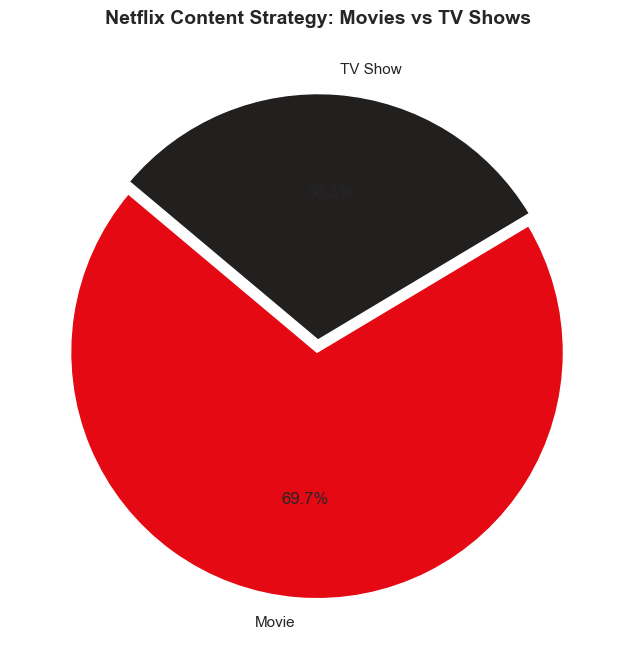

In [4]:
plt.figure(figsize=(8, 8))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
        colors=['#E50914', '#221F1F'], startangle=140, explode=(0.05, 0))
plt.title('Netflix Content Strategy: Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.show()

# Phase 5: Exploratory Data Analysis - Growth Velocity
Using the engineered 'year_added' column, we track the volume of content added to the platform over time.

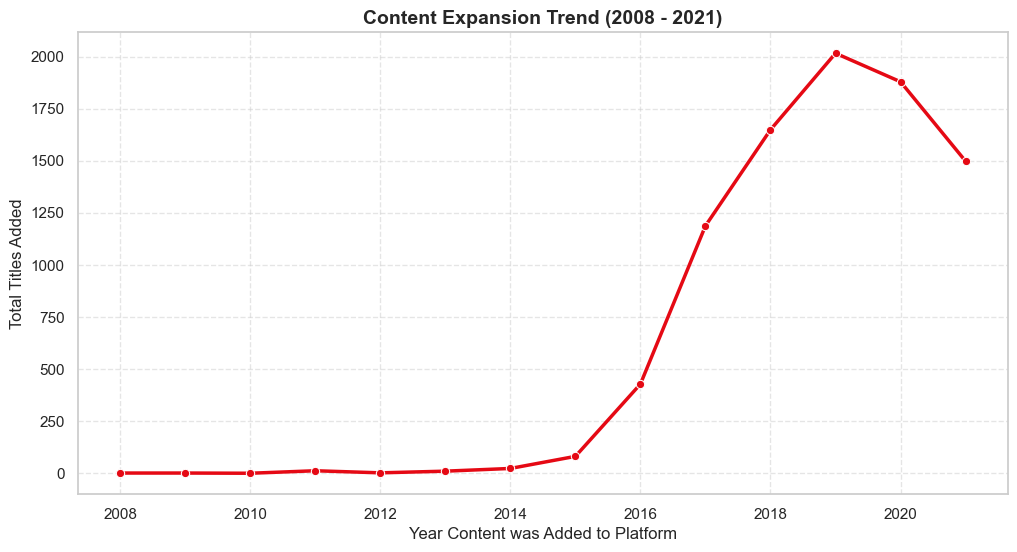

In [6]:
plt.figure(figsize=(12, 6))

# Grouping data by year and counting entries
growth_data = df.groupby('year_added').size()

# Creating the line plot
sns.lineplot(x=growth_data.index, y=growth_data.values, marker='o', color='#E50914', linewidth=2.5)

plt.title('Content Expansion Trend (2008 - 2021)', fontsize=14, fontweight='bold')
plt.xlabel('Year Content was Added to Platform')
plt.ylabel('Total Titles Added')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Phase 6: Geographic Analysis — Top 10 Producing Countries
Netflix is a global platform, but its production is concentrated in specific creative hubs. We parse the 'country' column to isolate the primary origin and identify the top 10 nations driving the majority of Netflix's catalog.

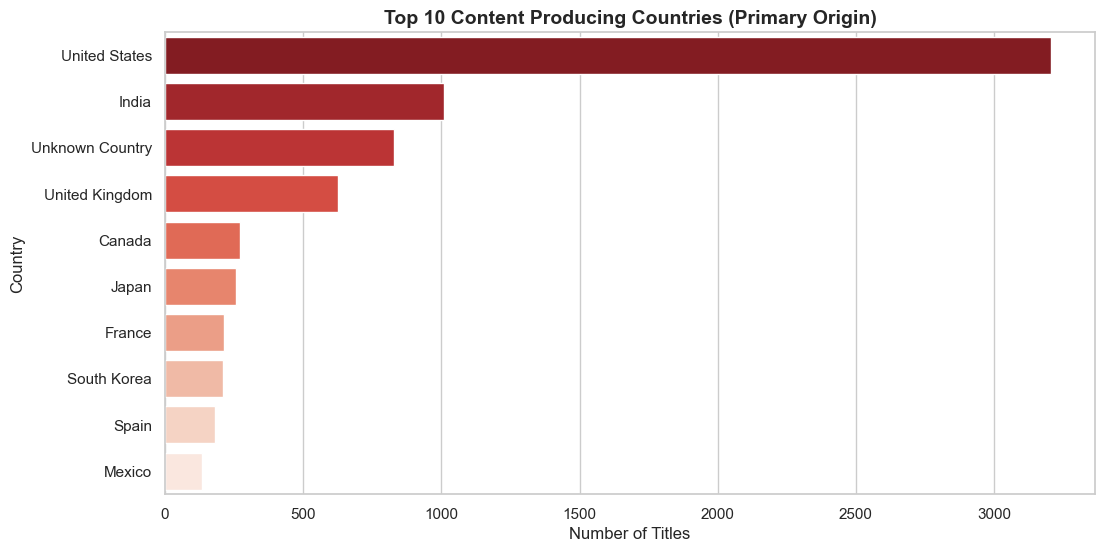

In [7]:
plt.figure(figsize=(12, 6))

df['primary_country'] = df['country'].str.split(',').str[0]
top_10_countries = df['primary_country'].value_counts().head(10)

sns.barplot(
    x=top_10_countries.values, 
    y=top_10_countries.index, 
    hue=top_10_countries.index, 
    palette='Reds_r', 
    legend=False
)

# Formatting the visual
plt.title('Top 10 Content Producing Countries (Primary Origin)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()